# Работа с целевой переменной

In [118]:
from sklearn.datasets import fetch_openml

df = fetch_openml("mtp", version=1)

df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


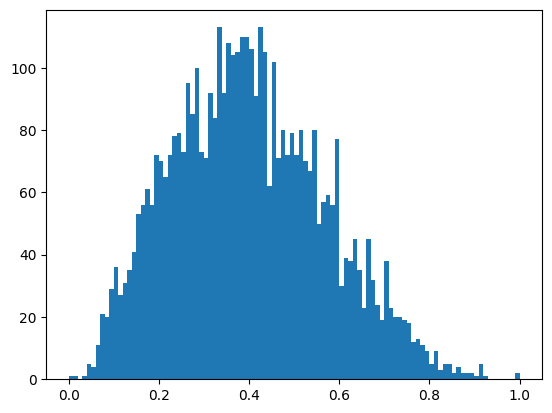

In [119]:
import matplotlib.pyplot as plt
plt.hist(df.target, 100)
_ = plt.plot()

In [120]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [121]:

from sklearn.linear_model import LinearRegression

baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.651134076973218

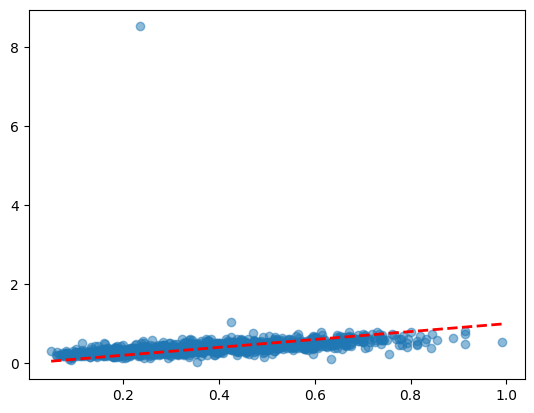

In [122]:
plt.scatter(y_test, baseline.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

Text(0.5, 0, 'Feature Importance')

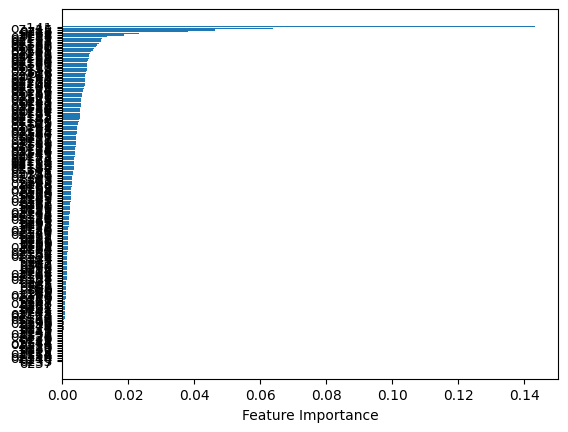

In [123]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel("Feature Importance")

In [124]:
rf.feature_importances_[sort][-10:]

array([0.01174014, 0.01176144, 0.01216823, 0.01367   , 0.01880268,
       0.0233168 , 0.03798408, 0.04629501, 0.06396099, 0.14312359])

In [125]:
df.data.columns[sort][-10:]

Index(['oz137', 'oz198', 'oz112', 'oz155', 'oz197', 'oz18', 'oz35', 'oz48',
       'oz15', 'oz141'],
      dtype='str')

In [126]:
trimmed = df.data[df.data.columns[sort][-20:]]
trimmed.head()

,oz156,oz169,oz153,oz56,oz201,oz158,oz161,oz20,oz180,oz162,oz137,oz198,oz112,oz155,oz197,oz18,oz35,oz48,oz15,oz141
0,0.288986,0.352613,0.052296,0.126277,0.127564,0.800120,0.382067,0.000000,0.002655,0.319206,0.000000,0.039213,0.000000,0.752291,0.505899,0.0625,0.0,0.312855,0.000000,0.041308
1,0.333151,0.352625,0.060922,0.422015,0.475618,0.791224,0.383458,0.242424,0.002581,0.306084,0.278945,0.326584,0.222222,0.745984,0.683820,0.0625,0.4,0.297041,0.282828,0.212274
2,0.362744,0.352400,0.072628,0.000000,0.497968,0.798276,0.382596,0.388889,0.002722,0.406309,0.000000,0.204885,0.000000,0.753298,0.499219,0.1250,0.0,0.288557,0.388889,0.063643
3,0.339485,0.352497,0.054593,0.000000,0.134458,0.800965,0.382776,0.095238,0.002473,0.327848,0.039437,0.023469,0.000000,0.767469,0.630533,0.0000,0.1,0.310692,0.111111,0.031193
4,0.292965,0.352417,0.045400,0.000000,0.295913,0.802893,0.383539,0.260870,0.002810,0.329857,0.000000,0.111398,0.000000,0.741548,0.516053,0.0625,0.0,0.286581,0.304348,0.063643


In [127]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.651134076973218


0.3753970221286531

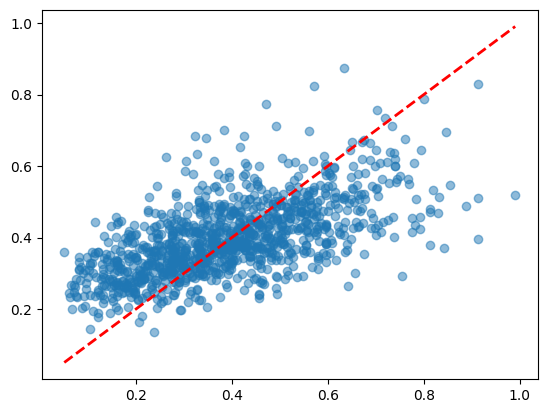

In [128]:
plt.scatter(y_test, better.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

In [129]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
X_trimmed.shape

(4450, 50)

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.651134076973218


0.43133584736080144

[ 3.83587761e-01 -4.00989683e-01  2.43055987e-01  2.79196175e-01
  2.30996999e-01  8.73735251e-02 -9.74511869e-02 -5.35718851e-02
 -8.13262375e-02  2.40383799e-02  7.89532244e-02  1.51343900e-02
  1.59309416e-01 -4.36449326e-02  1.25293952e-01  3.23768401e-01
 -2.59413638e-02  2.60528586e-02 -6.46580750e-02  4.53897587e-02
  1.28751870e-01 -9.45883976e-02 -2.82419100e-01  6.98137049e-02
 -5.11043281e-02 -3.20714330e-02  5.80773877e-02 -1.95782167e+00
  9.02206784e-01  2.89588000e+01 -3.86836218e+01  4.59348600e-01
 -5.10540345e-01  1.93594454e-01  2.99385270e+00  8.37545594e-02
  2.39624989e-01  3.06176213e+01  1.93037957e-01 -1.78919176e-01
  6.65237544e-02 -1.32853487e-01 -1.31615575e-01 -2.22017637e-03
  2.06510376e-02 -3.36464181e-01  2.59815659e-01  8.49946013e-02
 -7.39659168e-02 -2.01097632e-01]
-14.517886118645979
0.43133584736080144


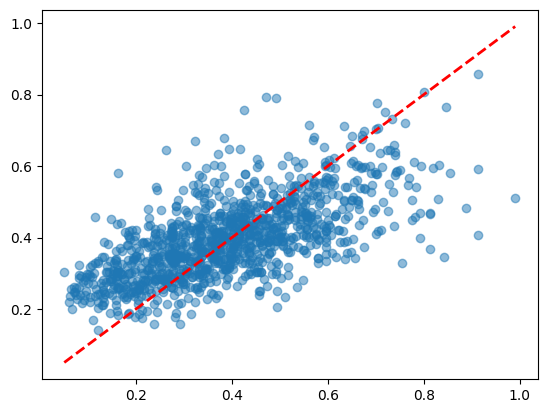

In [131]:
from sklearn.metrics import r2_score
print(better.coef_)
print(better.intercept_)
print(r2_score(y_test, better.predict(X_test)))

plt.scatter(y_test, better.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

In [132]:
df = fetch_openml("balance-scale", version=1)

df.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


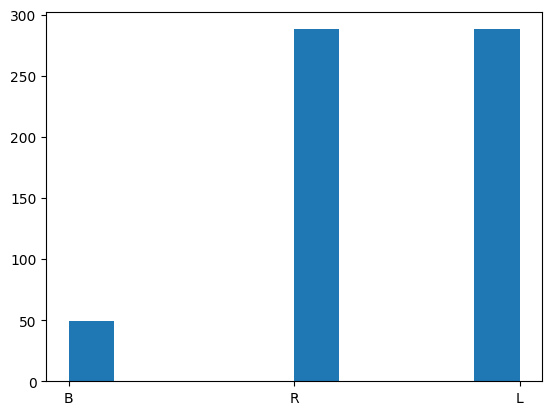

In [133]:
plt.hist(df.target)
plt.show()

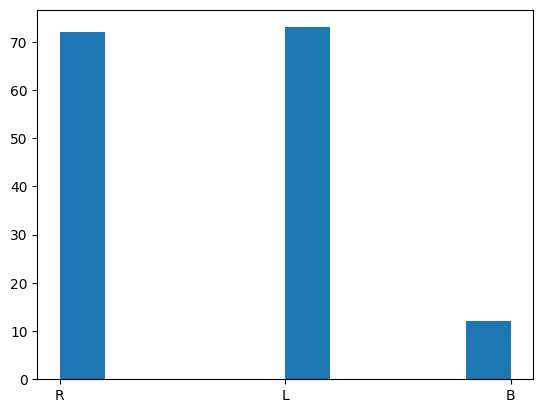

In [134]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

plt.hist(y_test)
plt.show()

In [135]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

0.8598726114649682

In [136]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157



In [137]:
print(confusion_matrix(y_test, baseline.predict(X_test)))

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


In [138]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': np.float64(4.216216216216216),
 'L': np.float64(0.7255813953488373),
 'R': np.float64(0.7222222222222222)}

In [139]:
weighted = LogisticRegression(class_weight=class_weights)
weighted.fit(X_train, y_train)
print(bl_score)
weighted.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [140]:
y_train.value_counts()

class
R    216
L    215
B     37
Name: count, dtype: int64

In [141]:
import pandas as pd

X_train["target"] = y_train
oversampled = X_train[X_train.target == "B"].sample(n=216-37, replace=True, ignore_index=True)
oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
oversampled.head()

(647, 5)


,left-weight,left-distance,right-weight,right-distance,target
262,3,1,3,3,R
401,4,2,1,2,L
174,2,2,5,5,R
81,1,4,2,2,B
36,1,2,3,2,R


In [142]:
y_train.value_counts()

class
R    216
L    215
B     37
Name: count, dtype: int64

In [143]:
X_train["target"] = y_train
oversampled = X_train[X_train.target == "B"].sample(n=216-37, replace=True, ignore_index=True)
oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
oversampled.head()

(647, 5)


,left-weight,left-distance,right-weight,right-distance,target
262,3,1,3,3,R
401,4,2,1,2,L
174,2,2,5,5,R
81,1,4,2,2,B
36,1,2,3,2,R


In [144]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop(["target"], axis=1)

OSmodel = LogisticRegression()
OSmodel.fit(X_train_OS, y_train_OS)
print(bl_score)
OSmodel.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

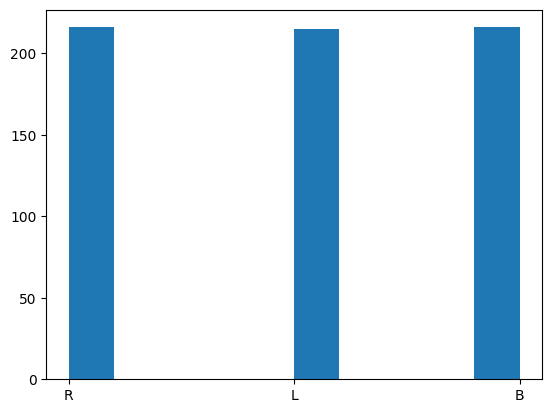

In [145]:
plt.hist(y_train_OS)
plt.show()

In [146]:
df = fetch_openml("CPMP-2015-regression", version=1)
df.data.drop(["instance_id"], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)
df.data.head()

,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


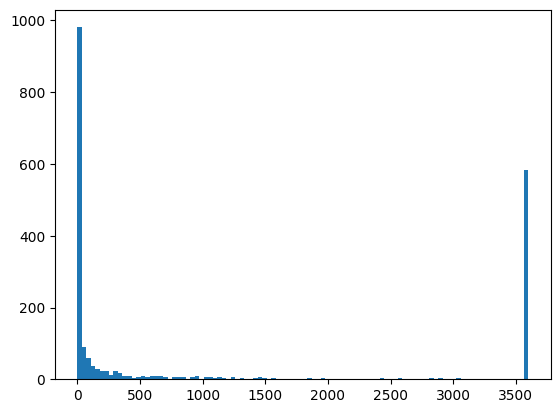

In [147]:
plt.hist(df.target, 100)
_ = plt.plot()

In [180]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [149]:
from sklearn.preprocessing import KBinsDiscretizer

y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform").fit_transform(pd.DataFrame(y_train))
y_binned

array([[4.],
       [0.],
       [4.],
       ...,
       [0.],
       [0.],
       [4.]], shape=(1581, 1))

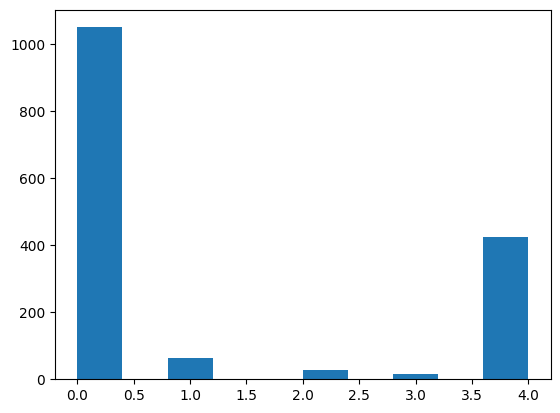

In [150]:
plt.hist(y_binned)
plt.show()

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


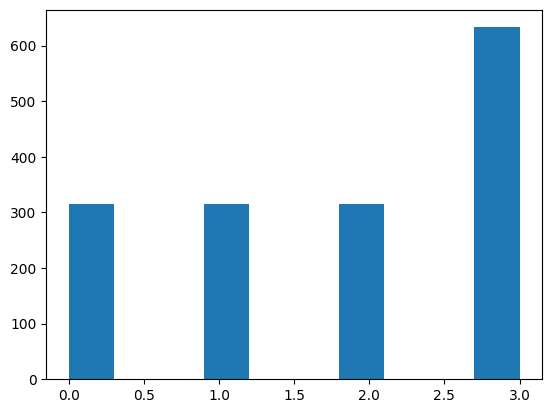

In [151]:
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

plt.hist(y_binned)
plt.show()

## Задания для самостоятельного выполнения

#### 1. Исследуйте связь между количеством самых важных признаков, которые использует модель для обучения и тестовой точностью получившейся модели. Обучите несколько моделей с разным количеством наиболее важных признаков. Постройте график зависимости точности модели от количества признаков. Сделайте вывод.

,n_features,r2
0,5,0.286146
1,10,0.346459
2,15,0.360698
3,20,0.367103
4,30,0.375940
5,40,0.427499
6,55,0.440982
7,80,0.455728
8,120,0.459491
9,202,-1.651134


Лучший результат: R2=0.4595 при количестве признаков=120


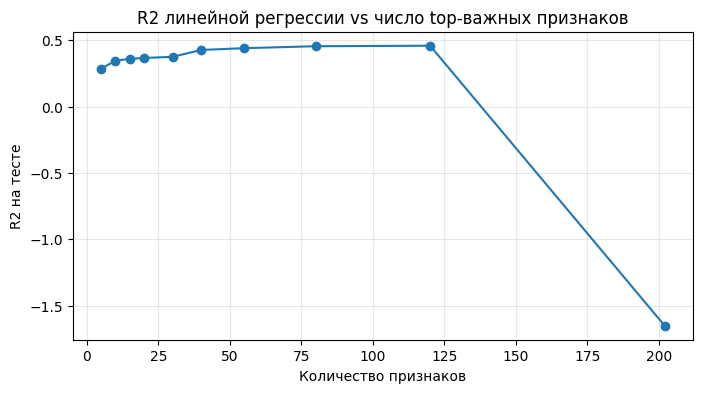

In [172]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df_reg = fetch_openml("mtp", version=1)
X_reg = df_reg.data.copy()
y_reg = pd.to_numeric(df_reg.target)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

rf_ranker = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_ranker.fit(X_train_reg, y_train_reg)

feature_order = np.argsort(rf_ranker.feature_importances_)[::-1]
feature_counts = [5, 10, 15, 20, 30, 40, 55, 80, 120, X_train_reg.shape[1]]

results = []
for k in feature_counts:
    selected_idx = feature_order[:k]
    selected_columns = X_train_reg.columns[selected_idx]

    model = LinearRegression()
    model.fit(X_train_reg[selected_columns], y_train_reg)
    y_pred = model.predict(X_test_reg[selected_columns])
    score = r2_score(y_test_reg, y_pred)

    results.append((k, score))

res_df = pd.DataFrame(results, columns=["n_features", "r2"])
display(res_df)

best_row = res_df.loc[res_df["r2"].idxmax()]
print(f"Лучший результат: R2={best_row['r2']:.4f} при количестве признаков={int(best_row['n_features'])}")

plt.figure(figsize=(8, 4))
plt.plot(res_df["n_features"], res_df["r2"], marker="o")
plt.title("R2 линейной регрессии vs число top-важных признаков")
plt.xlabel("Количество признаков")
plt.ylabel("R2 на тесте")
plt.grid(alpha=0.3)
plt.show()


# Зависимость качества от количества признаков обычно имеет предел:
# слишком мало признаков дает недообучение, слишком много дает шум и падение обобщающей способности
# По таблице и графику выбираем количество признаков в районе максимального R2 на тесте
# Практически это подтверждает, что отбор признаков работает как регуляризация сложности модели

#### 2. Используйте другие методы отбора признаков:

#### a) Исключение низкодисперсных признаков

In [188]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_regression, RFE, SequentialFeatureSelector, SelectFromModel
)
from sklearn.metrics import r2_score

base_model = LinearRegression()
base_model.fit(X_train_reg, y_train_reg)
base_r2 = r2_score(y_test_reg, base_model.predict(X_test_reg))
print(f"Baseline (all features) R2: {base_r2:.4f}")

vt = VarianceThreshold(threshold=0.01)
X_train_vt = vt.fit_transform(X_train_reg)
X_test_vt = vt.transform(X_test_reg)
m_vt = LinearRegression().fit(X_train_vt, y_train_reg)
r2_vt = r2_score(y_test_reg, m_vt.predict(X_test_vt))
print(f"a) VarianceThreshold: {X_train_vt.shape[1]} features, R2={r2_vt:.4f}")

Baseline (all features) R2: -1.6511
a) VarianceThreshold: 134 features, R2=-1.4759


#### b) Исключение по парным стаистическим критериям (хи-квадрат, тест Фишера, коэффициент корреляции, информационный критерий)

In [189]:
skb = SelectKBest(score_func=f_regression, k=15)
X_train_skb = skb.fit_transform(X_train_reg, y_train_reg)
X_test_skb = skb.transform(X_test_reg)
m_skb = LinearRegression().fit(X_train_skb, y_train_reg)
r2_skb = r2_score(y_test_reg, m_skb.predict(X_test_skb))
print(f"b) SelectKBest(f_regression): {X_train_skb.shape[1]} features, R2={r2_skb:.4f}")

b) SelectKBest(f_regression): 15 features, R2=0.3032


#### c) Рекурсивное исключение признаков

In [190]:
rfe = RFE(LinearRegression(), n_features_to_select=15, step=10)
X_train_rfe = rfe.fit_transform(X_train_reg, y_train_reg)
X_test_rfe = rfe.transform(X_test_reg)
m_rfe = LinearRegression().fit(X_train_rfe, y_train_reg)
r2_rfe = r2_score(y_test_reg, m_rfe.predict(X_test_rfe))
print(f"c) RFE: {X_train_rfe.shape[1]} features, R2={r2_rfe:.4f}")

c) RFE: 15 features, R2=0.0797


#### d) Последовательное включение признаков

In [191]:
sfs = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=15, direction='forward', cv=3, n_jobs=-1
)
sfs.fit(X_train_reg, y_train_reg)
X_train_sfs = sfs.transform(X_train_reg)
X_test_sfs = sfs.transform(X_test_reg)
m_sfs = LinearRegression().fit(X_train_sfs, y_train_reg)
r2_sfs = r2_score(y_test_reg, m_sfs.predict(X_test_sfs))
print(f"d) SequentialFeatureSelector: {X_train_sfs.shape[1]} features, R2={r2_sfs:.4f}")

d) SequentialFeatureSelector: 15 features, R2=0.4369


#### e) Исключение по L1-норме (гребневой регрессии)

In [192]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler_l1 = StandardScaler()
X_train_reg_scaled = scaler_l1.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_l1.transform(X_test_reg)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_train_reg_scaled, y_train_reg)
sfm_l1 = SelectFromModel(lasso_cv, prefit=True, threshold='mean')
X_train_l1 = sfm_l1.transform(X_train_reg_scaled)
X_test_l1 = sfm_l1.transform(X_test_reg_scaled)

m_l1 = LinearRegression().fit(X_train_l1, y_train_reg)
r2_l1 = r2_score(y_test_reg, m_l1.predict(X_test_l1))
print(f"e) L1 (LassoCV): {X_train_l1.shape[1]} features, R2={r2_l1:.4f}")

summary_fs = pd.DataFrame({
    'method': ['Baseline(all)', 'VarianceThreshold', 'SelectKBest', 'RFE', 'SFS', 'L1(LassoCV)'],
    'n_features': [X_train_reg.shape[1], X_train_vt.shape[1], X_train_skb.shape[1], X_train_rfe.shape[1], X_train_sfs.shape[1], X_train_l1.shape[1]],
    'r2': [base_r2, r2_vt, r2_skb, r2_rfe, r2_sfs, r2_l1]
}).sort_values('r2', ascending=False)
display(summary_fs)

e) L1 (LassoCV): 53 features, R2=0.4849


,method,n_features,r2
5,L1(LassoCV),53,0.484946
4,SFS,15,0.436879
2,SelectKBest,15,0.303236
3,RFE,15,0.079669
1,VarianceThreshold,134,-1.475851
0,Baseline(all),202,-1.651134


#### 3. Изучите возможности библиотеки imbalanced-learn. Примените на данном примере возможности данной библиотеки для оверсемплинга и андерсемплинга выборки.

In [194]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

df_bal = fetch_openml("balance-scale", version=1)
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    df_bal.data, df_bal.target, test_size=0.25, random_state=42, stratify=df_bal.target
)

def eval_model(X_tr, y_tr, X_te, y_te, name):
    model = LogisticRegression(max_iter=2000)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        'method': name,
        'accuracy': accuracy_score(y_te, pred),
        'macro_f1': f1_score(y_te, pred, average='macro'),
        'report': classification_report(y_te, pred)
    }

results_imb = []
results_imb.append(eval_model(X_train_bal, y_train_bal, X_test_bal, y_test_bal, 'baseline'))

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_bal, y_train_bal)
results_imb.append(eval_model(X_train_ros, y_train_ros, X_test_bal, y_test_bal, 'RandomOverSampler'))

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_bal, y_train_bal)
results_imb.append(eval_model(X_train_rus, y_train_rus, X_test_bal, y_test_bal, 'RandomUnderSampler'))

compare_imb = pd.DataFrame([{
    'method': r['method'], 'accuracy': r['accuracy'], 'macro_f1': r['macro_f1']
} for r in results_imb]).sort_values('macro_f1', ascending=False)
display(compare_imb)

for r in results_imb:
    print(f"\n{r['method']}")
    print(r['report'])

,method,accuracy,macro_f1
1,RandomOverSampler,0.923567,0.873552
2,RandomUnderSampler,0.872611,0.798328
0,baseline,0.859873,0.597999



baseline
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157


RandomOverSampler
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157


RandomUnderSampler
              precision    recall  f1-score   support

           B       0.41      0.92      0.56        12
           L       0.98      0.81      0.89        73
           R       0.96   

In [196]:
compare_imb

,method,accuracy,macro_f1
1,RandomOverSampler,0.923567,0.873552
2,RandomUnderSampler,0.872611,0.798328
0,baseline,0.859873,0.597999


In [197]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_bal, y_train_bal)
smote_row = eval_model(X_train_smote, y_train_smote, X_test_bal, y_test_bal, 'SMOTE')
print(pd.DataFrame([{'method': smote_row['method'], 'accuracy': smote_row['accuracy'], 'macro_f1': smote_row['macro_f1']}]))

  method  accuracy  macro_f1
0  SMOTE   0.88535  0.817464


In [198]:
compare_imb

,method,accuracy,macro_f1
1,RandomOverSampler,0.923567,0.873552
2,RandomUnderSampler,0.872611,0.798328
0,baseline,0.859873,0.597999


In [199]:
from imblearn.under_sampling import TomekLinks
tl = TomekLinks()
X_train_tl, y_train_tl = tl.fit_resample(X_train_bal, y_train_bal)
tl_row = eval_model(X_train_tl, y_train_tl, X_test_bal, y_test_bal, 'TomekLinks')
print(pd.DataFrame([{'method': tl_row['method'], 'accuracy': tl_row['accuracy'], 'macro_f1': tl_row['macro_f1']}]))

       method  accuracy  macro_f1
0  TomekLinks  0.872611   0.71928


#### 4. Исследуйте влияние дискретизации целевой переменной на качество модели. Используйте уже продемострированный подход - построение базовой модели (baseline) и сравнение модели после обработки данных с базовой. Проверьте разное количество категорий, а также разные стратегии группировки. Сделайте выводы. Обратите внимание, что после биннинга целевой переменной она стала категориальной. А значит, задача превратилась в задачу классификации.

Baseline regression R2 (до дискретизации): 0.8920


c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:39

,strategy,n_bins,dummy_acc,model_acc,model_macro_f1
4,quantile,3,0.311195,0.836812,0.828300
0,uniform,3,0.624288,0.941176,0.675687
5,quantile,5,0.459203,0.726755,0.647740
6,quantile,8,0.436433,0.669829,0.547130
1,uniform,5,0.599620,0.922201,0.462352
7,quantile,10,0.366224,0.584440,0.445508
2,uniform,8,0.574953,0.899431,0.298837
3,uniform,10,0.569260,0.893738,0.245021


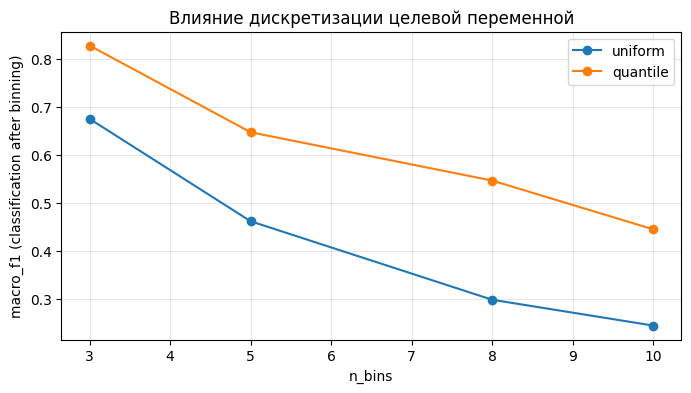

In [200]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.dummy import DummyClassifier

# Baseline регрессии (до дискретизации)
reg_baseline = LinearRegression().fit(X_train, y_train)
reg_r2 = r2_score(y_test, reg_baseline.predict(X_test))
print(f"Baseline regression R2 (до дискретизации): {reg_r2:.4f}")

bins_list = [3, 5, 8, 10]
strategies = ['uniform', 'quantile']
rows = []

for strategy in strategies:
    for n_bins in bins_list:
        kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy)
        y_train_binned = kbd.fit_transform(pd.DataFrame(y_train)).ravel().astype(int)
        y_test_binned = kbd.transform(pd.DataFrame(y_test)).ravel().astype(int)

        # baseline классификации после биннинга
        dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train_binned)
        dummy_pred = dummy.predict(X_test)

        # модель после обработки
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        clf.fit(X_train, y_train_binned)
        y_pred = clf.predict(X_test)

        rows.append({
            'strategy': strategy,
            'n_bins': n_bins,
            'dummy_acc': accuracy_score(y_test_binned, dummy_pred),
            'model_acc': accuracy_score(y_test_binned, y_pred),
            'model_macro_f1': f1_score(y_test_binned, y_pred, average='macro')
        })

binning_results = pd.DataFrame(rows).sort_values('model_macro_f1', ascending=False)
display(binning_results)

plt.figure(figsize=(8, 4))
for strategy in strategies:
    part = binning_results[binning_results['strategy'] == strategy].sort_values('n_bins')
    plt.plot(part['n_bins'], part['model_macro_f1'], marker='o', label=strategy)
plt.xlabel('n_bins')
plt.ylabel('macro_f1 (classification after binning)')
plt.title('Влияние дискретизации целевой переменной')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()